In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter

In [70]:
df = pd.read_csv("data/Position_Salaries.csv")

In [71]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [73]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [74]:
df.columns

Index(['Position', 'Level', 'Salary'], dtype='object')

In [75]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

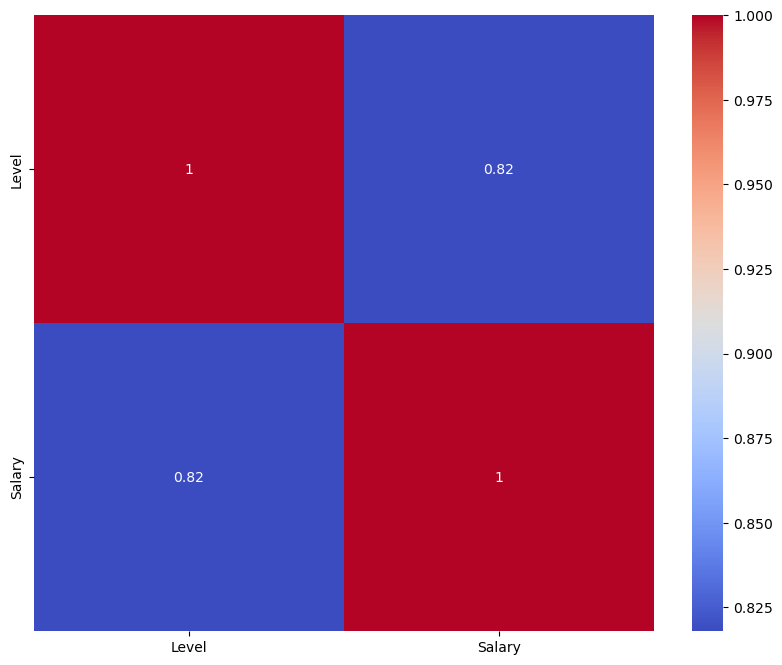

In [76]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()


In [77]:
X = df['Level'].values        # feature(s)
y = df['Salary'].values # target
X.shape
y.shape


(10,)

In [78]:
# Convert X to 2D column vector (n_samples, n_features)
X = X.reshape(-1, 1)

# Convert y to 2D column vector for scaling
y = y.reshape(-1, 1)


In [79]:

Scalar = StandardScaler()


X_scaled = Scalar.fit_transform(X)
y_scaled = Scalar.fit_transform(y)


In [80]:
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_scaled, y_scaled.ravel())  # y_scaled must be 1D here


,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [81]:
y_pred_scaled = svr_model.predict(X_scaled)


In [82]:
y_pred = Scalar.inverse_transform(y_pred_scaled.reshape(-1,1))


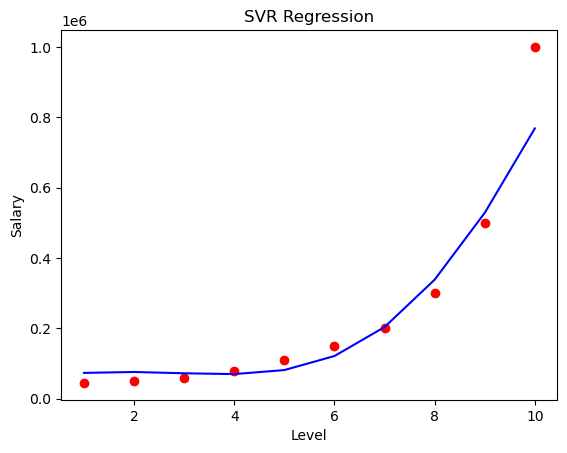

In [83]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='red')           # actual points
plt.plot(X, y_pred, color='blue')        # SVR predictions
plt.title("SVR Regression")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()
